# EfficientNet-B3 (Partial Unfreeze)

**Objective**: Previous experiments trained the full EfficientNet-B3 backbone end-to-end. This notebook explores whether freezing early layers (which capture generic low-level features) and only fine-tuning the last few blocks improves generalisation on the small HAM10000 dataset (~7,800 images).

**Architecture Changes**:
| Component | Previous iteration (EfficientNet-B3 Basic) | This iteration (EfficientNet-B3 Partial Unfreeze) |
|---|---|---|
| Backbone | Fully unfrozen | Last 3 blocks only |
| `unfreeze_last_n_blocks` | 0 (all) | 3 |

**Hypothesis**: Freezing early layers should reduce overfitting on the small dataset and let the model focus on adapting higher-level features specifically for melanoma detection.

## Import libraries, set seed, and choose device

In [1]:
import sys
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_train_transforms
from src.models.efficientnet import get_efficientnet
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

import pandas as pd

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    
)

_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


## Model Definition

In [3]:
UNFREEZE_LAST_N_BLOCKS = 3
model = get_efficientnet(num_classes=1, unfreeze_last_n_blocks=UNFREEZE_LAST_N_BLOCKS).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

num_epochs = 20

L1_LAMBDA = 0.0
L2_LAMBDA = 0.0
dropout = 0.0

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.1f}%)')
print(f'L1 lambda: {L1_LAMBDA} | L2 lambda: {L2_LAMBDA} | Dropout: {dropout}')

Trainable params: 8,507,615 / 10,697,769 (79.5%)
L1 lambda: 0.0 | L2 lambda: 0.0 | Dropout: 0.0


## Training Loop

In [4]:
best_val_auc = 0.0
train_history, val_history = [], []
MODEL_SAVE_PATH = str(ROOT / f'models/efficientnet_b3_partial_unfreeze_{UNFREEZE_LAST_N_BLOCKS}_best.pth')

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA,
    )
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/20]
  Train | Loss: 0.9386, Bal Acc: 0.7413, Recall: 0.8347, F2: 0.5426, AUC: 0.8160
  Val   | Loss: 0.8063, Bal Acc: 0.7640, Recall: 0.8686, F2: 0.5830, AUC: 0.8717
  -> Saved best model (val AUC: 0.8717)


Epoch [2/20]
  Train | Loss: 0.7225, Bal Acc: 0.8117, Recall: 0.8620, F2: 0.6341, AUC: 0.8946
  Val   | Loss: 0.7772, Bal Acc: 0.7981, Recall: 0.8814, F2: 0.6258, AUC: 0.8848
  -> Saved best model (val AUC: 0.8848)


Epoch [3/20]
  Train | Loss: 0.6094, Bal Acc: 0.8494, Recall: 0.8837, F2: 0.6921, AUC: 0.9267
  Val   | Loss: 0.8175, Bal Acc: 0.8018, Recall: 0.8263, F2: 0.6344, AUC: 0.8828


Epoch [4/20]
  Train | Loss: 0.5281, Bal Acc: 0.8796, Recall: 0.9054, F2: 0.7432, AUC: 0.9452
  Val   | Loss: 0.8583, Bal Acc: 0.7979, Recall: 0.8559, F2: 0.6269, AUC: 0.8858
  -> Saved best model (val AUC: 0.8858)


Epoch [5/20]
  Train | Loss: 0.4427, Bal Acc: 0.8961, Recall: 0.9202, F2: 0.7721, AUC: 0.9622
  Val   | Loss: 0.8607, Bal Acc: 0.8051, Recall: 0.7712, F2: 0.6436, AUC: 0.8935
  -> Saved best model (val AUC: 0.8935)


...

Epoch [16/20]
  Train | Loss: 0.1586, Bal Acc: 0.9651, Recall: 0.9715, F2: 0.9153, AUC: 0.9948
  Val   | Loss: 1.5251, Bal Acc: 0.7790, Recall: 0.6441, F2: 0.6080, AUC: 0.8872


Epoch [17/20]
  Train | Loss: 0.1401, Bal Acc: 0.9714, Recall: 0.9761, F2: 0.9304, AUC: 0.9959
  Val   | Loss: 1.3205, Bal Acc: 0.8058, Recall: 0.7331, F2: 0.6484, AUC: 0.8910


Epoch [18/20]
  Train | Loss: 0.1685, Bal Acc: 0.9609, Recall: 0.9612, F2: 0.9100, AUC: 0.9944
  Val   | Loss: 1.5295, Bal Acc: 0.7803, Recall: 0.6653, F2: 0.6095, AUC: 0.8755


Epoch [19/20]
  Train | Loss: 0.1428, Bal Acc: 0.9684, Recall: 0.9692, F2: 0.9263, AUC: 0.9961
  Val   | Loss: 1.4888, Bal Acc: 0.7938, Recall: 0.6737, F2: 0.6325, AUC: 0.8910


Epoch [20/20]
  Train | Loss: 0.1271, Bal Acc: 0.9716, Recall: 0.9738, F2: 0.9323, AUC: 0.9967
  Val   | Loss: 1.4011, Bal Acc: 0.7965, Recall: 0.7161, F2: 0.6339, AUC: 0.8879


## Plot Train and Validation Curves

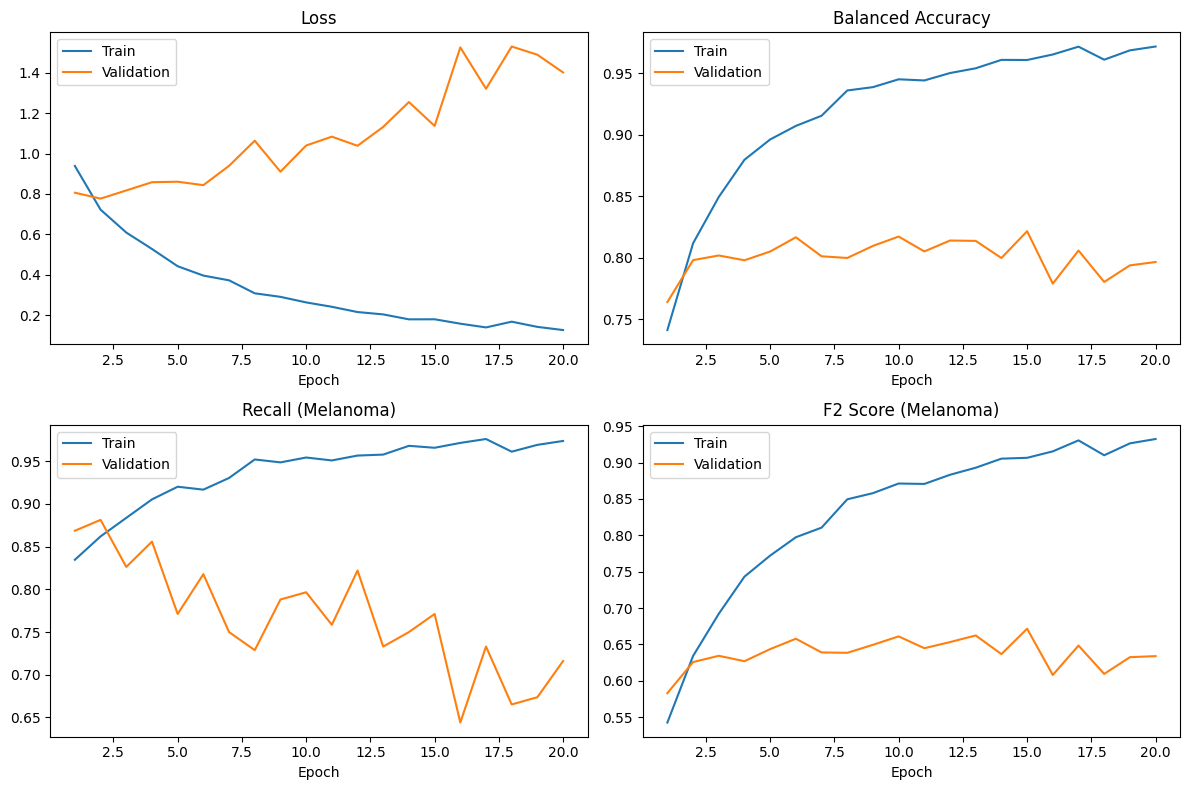

In [5]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [6]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

Best threshold: 0.39 | Val F2: 0.6913


## Test Set Evaluation

Threshold:          0.39
AUC-ROC:            0.8743
Balanced Accuracy:  0.7942
F2 Score:           0.6220

              precision    recall  f1-score   support

Non-Melanoma     0.9650    0.8224    0.8880      1340
    Melanoma     0.3550    0.7661    0.4852       171

    accuracy                         0.8160      1511
   macro avg     0.6600    0.7942    0.6866      1511
weighted avg     0.8959    0.8160    0.8424      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


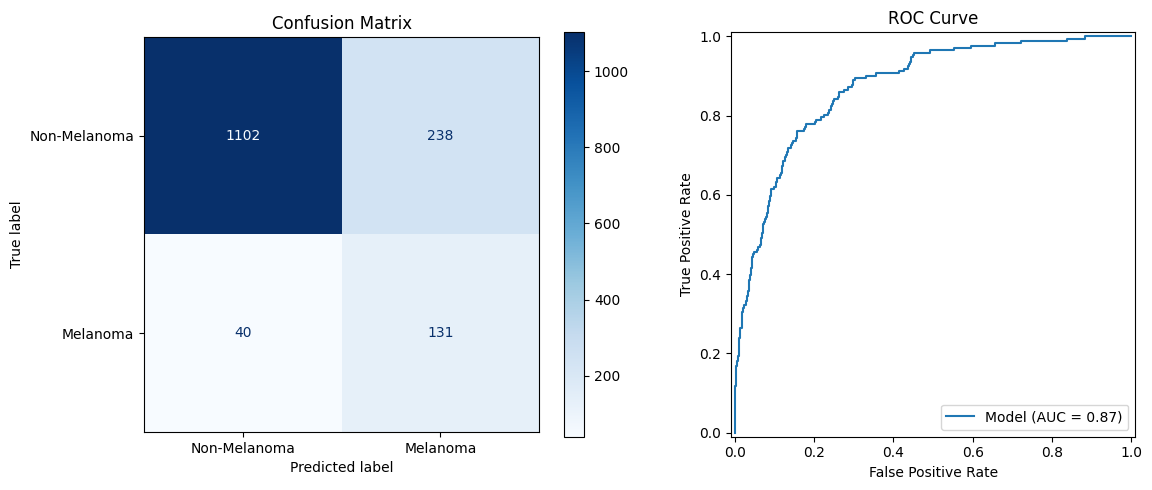

In [7]:
evaluate_model(model, test_loader, device, threshold=best_threshold)